<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Calculus/sympy/sympy_04_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Activation Function**

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20210103184807/ann.jpg">

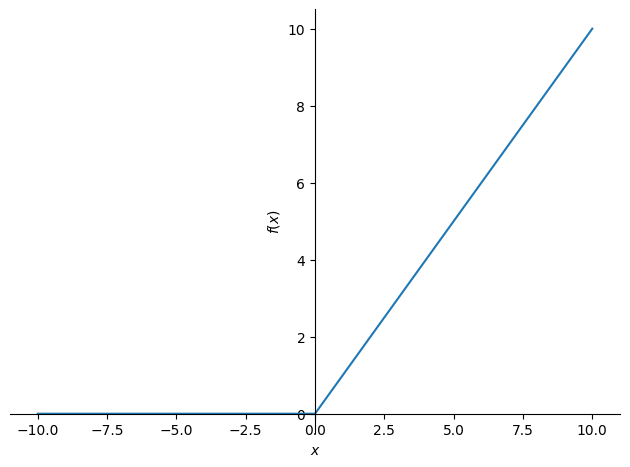

In [ ]:
from sympy import *

# 렐루 함수 그리기
x = symbols('x')
relu = Max(0, x)
plot(relu)

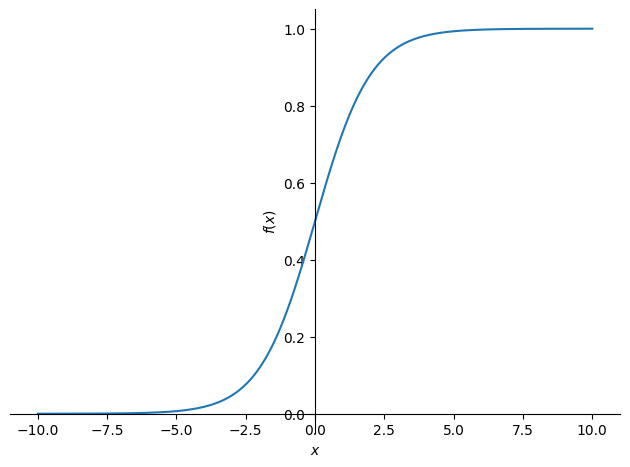

In [ ]:
# 로지스틱 그래프 그리기
logistic = 1 / (1 + exp(-x))
plot(logistic)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

all_data = pd.read_csv("https://bit.ly/3BVJ2ip")
all_data

,RED,GREEN,BLUE,LIGHT_OR_DARK_FONT_IND
0,0,0,0,1
1,0,0,128,1
2,0,0,139,1
3,0,0,205,1
4,0,0,238,1
...,...,...,...,...
1340,95,158,160,0
1341,96,123,139,1
1342,97,97,97,1
1343,99,184,255,0


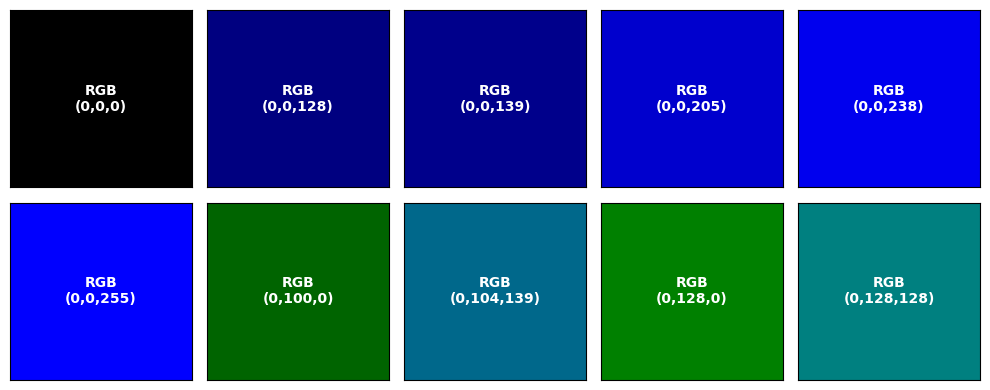

In [ ]:
import matplotlib.pyplot as plt

# 1. 상위 10개 데이터 추출
sample = all_data.head(10)

# 2. 2행 5열 서브플롯 생성
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

# 3. 반복문을 통한 시각화
for i, ax in enumerate(axes):
    row = sample.iloc[i]
    r, g, b = int(row['RED']), int(row['GREEN']), int(row['BLUE'])

    # 배경색(RGB 0~1 정규화) 및 글자색(인디케이터 반영) 설정
    ax.set_facecolor((r/255, g/255, b/255))
    text_color = 'white' if row['LIGHT_OR_DARK_FONT_IND'] == 1 else 'black'

    # 텍스트 중앙 표시 및 축 숨기기
    ax.text(0.5, 0.5, f"RGB\n({r},{g},{b})", color=text_color, weight='bold', ha='center', va='center')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
# 입력 값을 추출하여 255로 나누기 : 자료 scaling
all_inputs = (all_data.iloc[:, 0:3].values / 255.0)
all_outputs = all_data.iloc[:, -1].values

# 훈련 데이터와 테스트 데이터로 분할
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs, test_size=1/3)
n = X_train.shape[0] # 훈련 샘플 개수

print(X_train.shape)
print(Y_train.shape)

(896, 3)
(896,)


## **1. pytorch from the scratch**

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQrkuB70ZVUtHQS96169hvC4iHRg_gaAkdgDQ&s">

In [ ]:
import torch
import torch.nn.functional as F

# Hyperparameters
learning_rate, epochs = 0.01, 300

# Convert NumPy arrays to PyTorch Tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float().reshape(-1, 1)

# Re-initialize parameters
W = torch.randn(3, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Training Loop
for epoch in range(epochs):
    # 1. Forward pass: 선형 결합 후 시그모이드 활성화 함수를 직접 적용 (예측 확률 계산)
    logits = X_train_tensor @ W + b
    y_hat = torch.sigmoid(logits)  # 0 ~ 1 사이의 확률 값

    # 2. Loss: 이미 시그모이드를 거친 y_hat을 사용하므로 binary_cross_entropy를 사용
    # 수치 안정성을 위해 아주 작은 값(eps)을 더해 로그 안이 0이 되는 것을 방지하는 것이 좋습니다.
    loss = F.binary_cross_entropy(y_hat, Y_train_tensor)

    # Backward pass
    loss.backward()

    # Update parameters
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # Zero gradients
    W.grad.zero_()
    b.grad.zero_()

    if epoch % 30 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.5078661441802979
Epoch 30, Loss: 1.3640906810760498
Epoch 60, Loss: 1.2439006567001343
Epoch 90, Loss: 1.1458989381790161
Epoch 120, Loss: 1.0676605701446533
Epoch 150, Loss: 1.0061852931976318
Epoch 180, Loss: 0.9583576321601868
Epoch 210, Loss: 0.9212886095046997
Epoch 240, Loss: 0.8925027847290039
Epoch 270, Loss: 0.8699913620948792


In [ ]:
W, b

(tensor([[ 0.4608],
         [ 1.7618],
         [-1.0948]], requires_grad=True),
 tensor([-0.9951], requires_grad=True))

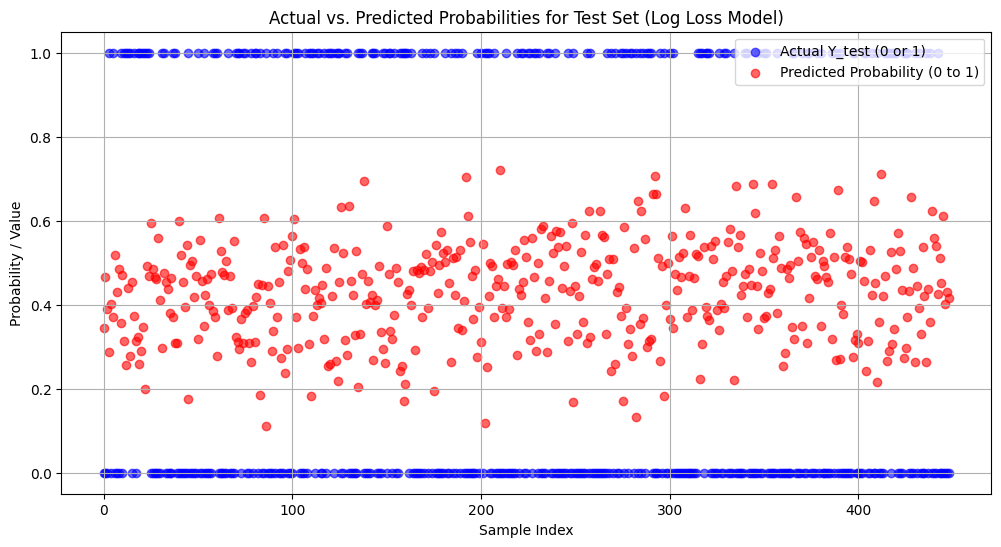

In [ ]:
import matplotlib.pyplot as plt
import torch

# 테스트 데이터 텐서 변환
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float().reshape(-1, 1)

# [수정 포인트] 예측 시 반드시 시그모이드를 씌워 확률값으로 만듭니다.
with torch.no_grad():
    logits = X_test_tensor @ W + b
    y_hat_test = torch.sigmoid(logits)  # 음수값을 0~1 사이 확률로 압축!

# 시각화를 위해 넘파이 배열로 변환
y_hat_test_np = y_hat_test.numpy().flatten()
Y_test_np = Y_test_tensor.numpy().flatten()

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.scatter(range(len(Y_test_np)), Y_test_np, alpha=0.6, label='Actual Y_test (0 or 1)', color='blue')
# 이제 이 빨간 점들은 확률(0~1)을 나타냅니다.
plt.scatter(range(len(y_hat_test_np)), y_hat_test_np, alpha=0.6, label='Predicted Probability (0 to 1)', color='red')

plt.title('Actual vs. Predicted Probabilities for Test Set (Log Loss Model)')
plt.xlabel('Sample Index')
plt.ylabel('Probability / Value')
plt.ylim(-0.05, 1.05)  # Y축을 0과 1 사이로 보기 좋게 제한
plt.legend()
plt.grid(True)
plt.show()

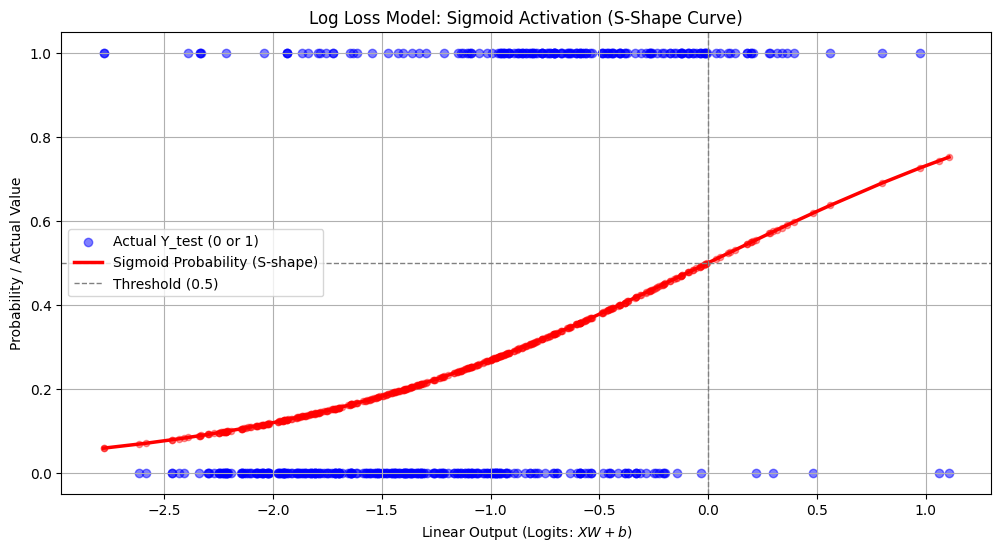

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Re-declare W and b with their trained PyTorch tensor values
# These values are taken from the output of cell ySGK6bZuA3Wo after training
W = torch.tensor([[-1.2498], [ 0.6815], [-2.1825]], requires_grad=True)
b = torch.tensor([0.4248], requires_grad=True)

# 1. 테스트 데이터 예측값(Logits) 및 확률 계산
with torch.no_grad():
    logits = (X_test_tensor @ W + b).flatten()      # -inf ~ +inf 값
    y_hat_test = torch.sigmoid(logits).flatten()   # 0 ~ 1 사이 확률 값

# 2. 넘파이 배열로 변환
logits_np = logits.numpy()
y_hat_test_np = y_hat_test.numpy()
Y_test_np = Y_test_tensor.numpy().flatten()

# 3. [핵심] X축을 선형 출력(Logits) 기준으로 정렬하기 위해 인덱스 정렬
sort_idx = np.argsort(logits_np)

# 4. 정렬된 데이터 준비
logits_sorted = logits_np[sort_idx]
y_hat_sorted = y_hat_test_np[sort_idx]
Y_test_sorted = Y_test_np[sort_idx]

# 5. 그래프 그리기
plt.figure(figsize=(12, 6))

# 실제 정답(0 또는 1) - 정렬된 Logits 위치에 점으로 표시
plt.scatter(logits_sorted, Y_test_sorted, alpha=0.5, color='blue', label='Actual Y_test (0 or 1)', zorder=1)

# 예측 확률 - 예쁜 S자 선(Line)과 점으로 표시
plt.plot(logits_sorted, y_hat_sorted, color='red', linewidth=2.5, label='Sigmoid Probability (S-shape)')
plt.scatter(logits_sorted, y_hat_sorted, color='red', alpha=0.4, s=20, zorder=2)

# 그래프 서식 설정
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Threshold (0.5)')
plt.axvline(0.0, color='gray', linestyle='--', linewidth=1)
plt.title('Log Loss Model: Sigmoid Activation (S-Shape Curve)')
plt.xlabel('Linear Output (Logits: $XW+b$)')
plt.ylabel('Probability / Actual Value')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## **2. Numpy from the scratch**

### 모델 설정

- 입력 변수 3개를 받아 은닉층 뉴런 3개를 거친 뒤, 최종 결과물 1개를 출력하는 3층 짜리 인공신경망의 뼈대를 무작위 숫자로 시작하는 코드"

- parameters(w, b)를 무작위로 초기화하여 예측해 보기 (Poor Guess ! NO Surprise)

In [ ]:
# 신경망의 가중치와 편향을 랜덤하게 초기화
w_hidden = np.random.rand(3, 3)
w_output = np.random.rand(1, 3)

b_hidden = np.random.rand(3, 1)
b_output = np.random.rand(1, 1)

# 활성화 함수
relu = lambda x: np.maximum(x, 0)
logistic = lambda x: 1 / (1 + np.exp(-x))

# 입력을 신경망에 통과시키고 출력을 얻습니다
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

# 정확도를 계산합니다
test_predictions = forward_prop(X_test.transpose())[3] # grab only output layer, A2
test_comparisons = np.equal((test_predictions >= .5).flatten().astype(int), Y_test)
accuracy = sum(test_comparisons.astype(int) / X_test.shape[0])
print("정확도: ", accuracy)

정확도:  0.40089086859688244


In [ ]:
from sympy import *

Z2 = symbols('Z2')

logistic = lambda x: 1 / (1 + exp(-x))

A2 = logistic(Z2)
dA2_dZ2 = diff(A2, Z2)
dA2_dZ2

exp(-Z2)/(1 + exp(-Z2))**2

In [ ]:
A1, W2, B2 = symbols('A1, W2, B2')

Z2 = A1*W2 + B2
dZ2_dW2 = diff(Z2, W2)
dZ2_dW2

A1

In [ ]:
W1, W2, B1, B2, A1, A2, Z1, Z2, X, Y = \
    symbols('W1 W2 B1 B2 A1 A2 Z1 Z2 X Y')

# A2에 대한 비용 함수의 도함수
C = (A2 - Y)**2
dC_dA2 = diff(C, A2)
print("dC_dA2 = ", dC_dA2) # 2*A2 - 2*Y

# Z2에 대한 A2의 도함수
logistic = lambda x: 1 / (1 + exp(-x))
_A2 = logistic(Z2)
dA2_dZ2 = diff(_A2, Z2)
print("dA2_dZ2 = ", dA2_dZ2) # exp(-Z2)/(1 + exp(-Z2))**2

# A1에 대한 Z2의 도함수
_Z2 = A1*W2 + B2
dZ2_dA1 = diff(_Z2, A1)
print("dZ2_dA1 = ", dZ2_dA1) # W2

# W2에 대한 Z2의 도함수
dZ2_dW2 = diff(_Z2, W2)
print("dZ2_dW2 = ", dZ2_dW2) # A1

# B2에 대한 Z2의 도함수
dZ2_dB2 = diff(_Z2, B2)
print("dZ2_dB2 = ", dZ2_dB2) # 1

# Z1에 대한 A1의 도함수
relu = lambda x: Max(x, 0)
_A1 = relu(Z1)

d_relu = lambda x: x > 0 # 양수이면 기울기가 1, 그렇지 않으면 0
dA1_dZ1 = d_relu(Z1)
print("dA1_dZ1 = ", dA1_dZ1) # Z1 > 0

# W1에 대한 Z1의 도함수
_Z1 = X*W1 + B1
dZ1_dW1 = diff(_Z1, W1)
print("dZ1_dW1 = ", dZ1_dW1) # X

# B1에 대한 Z1의 도함수
dZ1_dB1 = diff(_Z1, B1)
print("dZ1_dB1 = ", dZ1_dB1) # 1

dC_dA2 =  2*A2 - 2*Y
dA2_dZ2 =  exp(-Z2)/(1 + exp(-Z2))**2
dZ2_dA1 =  W2
dZ2_dW2 =  A1
dZ2_dB2 =  1
dA1_dZ1 =  Z1 > 0
dZ1_dW1 =  X
dZ1_dB1 =  1


In [ ]:
all_data = pd.read_csv("https://bit.ly/3BVJ2ip")

# 학습률은 솔루션에 얼마나 느리게 도착할지 제어
# 너무 작으면 오랜 시간이 걸리고 너무 크면 솔루션을 지나치거나 놓쳐버림
L = 0.05

# 입력 열을 추출해 255로 나누어 자료 표준화
all_inputs = (all_data.iloc[:, 0:3].values / 255.0)
all_outputs = all_data.iloc[:, -1].values

# 훈련 데이터셋과 테스트 데이터셋으로 나누기
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs,
    test_size=1 / 3)
n = X_train.shape[0]

# 랜덤하게 초기화한 가중치와 편향으로 신경망을 만들기
w_hidden = np.random.rand(3, 3)
w_output = np.random.rand(1, 3)

b_hidden = np.random.rand(3, 1)
b_output = np.random.rand(1, 1)

# 활성화 함수
relu = lambda x: np.maximum(x, 0)
logistic = lambda x: 1 / (1 + np.exp(-x))

# 입력을 신경망에 통과시키고 예측 출력을 얻기 : Feed Forward
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

# 활성화 함수의 도함수
d_relu = lambda x: x > 0
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

# 연쇄 법칙을 사용해 가중치와 편향의 그레이디언트를 반환
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2 * A2 - 2 * Y
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1
    dA1_dZ1 = d_relu(Z1)
    dZ1_dW1 = X
    dZ1_dB1 = 1

    dC_dW2 = dC_dA2 @ dA2_dZ2 @ dZ2_dW2.T

    dC_dB2 = dC_dA2 @ dA2_dZ2 * dZ2_dB2

    dC_dA1 = dC_dA2 @ dA2_dZ2 @ dZ2_dA1

    dC_dW1 = dC_dA1 @ dA1_dZ1 @ dZ1_dW1.T

    dC_dB1 = dC_dA1 @ dA1_dZ1 * dZ1_dB1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

# 경사 하강법을 실행 (Stochastic Gradient Descent)
for i in range(100_000):
    # 훈련 데이터에서 하나의 샘플을 랜덤하게 선택
    idx = np.random.choice(n, 1, replace=False)
    X_sample = X_train[idx].transpose()
    Y_sample = Y_train[idx]

    # 선택한 샘플을 신경망에 통과
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    # 역전파를 통해 오차를 전파하고 가중치와 편향에 대한 그레이디언트를 구하기 (방향을 찾고)
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # 가중치와 편향을 업데이트하기 (방향만큼 움직이기)
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2

# 정확도를 계산
test_predictions = forward_prop(X_test.transpose())[3]  # A2만 저장
test_comparisons = np.equal((test_predictions >= .5).flatten().astype(int), Y_test)
accuracy = sum(test_comparisons.astype(int) / X_test.shape[0])
print("정확도: ", accuracy)

정확도:  0.9955456570155826


In [ ]:
# 새로운 색깔을 테스트하기
def predict_probability(r, g, b):
    X = np.array([[r, g, b]]).transpose() / 255
    Z1, A1, Z2, A2 = forward_prop(X)
    return A2

def predict_font_shade(r, g, b):
    output_values = predict_probability(r, g, b)
    if output_values > .5:
        return "LIGHT"
    else:
        return "DARK"

col_input = input("밝은 글꼴과 어두운 글꼴을 예측합니다. R,G,B를 입력하세요: ")
(r, g, b) = col_input.split(",")
print(predict_font_shade(int(r), int(g), int(b)))

밝은 글꼴과 어두운 글꼴을 예측합니다. R,G,B를 입력하세요: 1,2,3
LIGHT


In [ ]:
import pandas as pd
# 데이터 로드하기
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

df = pd.read_csv('https://bit.ly/3GsNzGt', delimiter=",")

# 입력 변수(마지막 열을 제외한 모든 열)를 추출하고 255로 나눕니다.
X = (df.values[:, :-1] / 255.0)

# 출력 열(마지막 열)을 추출합니다.
Y = df.values[:, -1]

# 훈련 데이터와 테스트 데이터를 나눕니다.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/3)

nn = MLPClassifier(solver='sgd',
                   hidden_layer_sizes=(3, ),
                   activation='relu',
                   max_iter=100_000,
                   learning_rate_init=.05)

nn.fit(X_train, Y_train)

# 가중치와 편향을 출력합니다.
print(nn.coefs_ )
print(nn.intercepts_)

print("훈련 세트 점수: %f" % nn.score(X_train, Y_train))
print("테스트 세트 점수: %f" % nn.score(X_test, Y_test))

[array([[-0.5258643 ,  3.36169398, -0.16624654],
       [-0.03684022,  7.0719278 ,  0.37142263],
       [-0.50796931,  1.18003571, -0.73289656]]), array([[ 0.12127261],
       [ 9.30867726],
       [-1.50862403]])]
[array([-0.25164757, -5.02068454,  1.75263849]), array([-4.9553939])]
훈련 세트 점수: 0.997768
테스트 세트 점수: 0.995546


### 학습과정 정확도 시각화

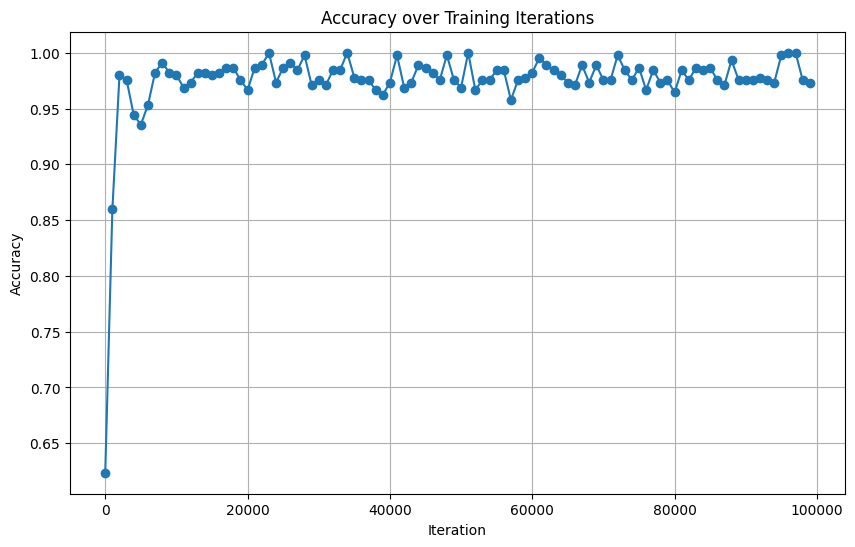

Final accuracy: 0.973273942093534


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Re-initialize weights and biases
w_hidden = np.random.rand(3, 3)
w_output = np.random.rand(1, 3)

b_hidden = np.random.rand(3, 1)
b_output = np.random.rand(1, 1)

# Redefine activation functions
relu = lambda x: np.maximum(x, 0)
logistic = lambda x: 1 / (1 + np.exp(-x))

# Redefine forward_prop function
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

# Redefine activation function derivatives
d_relu = lambda x: x > 0
d_logistic = lambda x: np.exp(-x) / (1 + np.exp(-x)) ** 2

# Redefine backward_prop function
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2 * A2 - 2 * Y
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dZ2_dW2 = A1
    dZ2_dB2 = 1
    dA1_dZ1 = d_relu(Z1)
    dZ1_dW1 = X
    dZ1_dB1 = 1

    dC_dW2 = dC_dA2 @ dA2_dZ2 @ dZ2_dW2.T

    dC_dB2 = dC_dA2 @ dA2_dZ2 * dZ2_dB2

    dC_dA1 = dC_dA2 @ dA2_dZ2 @ dZ2_dA1

    dC_dW1 = dC_dA1 @ dA1_dZ1 @ dZ1_dW1.T

    dC_dB1 = dC_dA1 @ dA1_dZ1 * dZ1_dB1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

# Lists to store accuracy history
accuracy_history = []
iteration_steps = []

# Learning rate (L) and number of training samples (n) are available from kernel state
# X_train, X_test, Y_train, Y_test are also available from kernel state

# Perform training and record accuracy
for i in range(100_000):
    # Randomly select one sample from the training data
    idx = np.random.choice(n, 1, replace=False)
    X_sample = X_train[idx].transpose()
    Y_sample = Y_train[idx]

    # Forward propagation
    Z1, A1, Z2, A2 = forward_prop(X_sample)

    # Backward propagation to get gradients
    dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

    # Update weights and biases
    w_hidden -= L * dW1
    b_hidden -= L * dB1
    w_output -= L * dW2
    b_output -= L * dB2

    # Record accuracy every 1000 iterations
    if i % 1000 == 0:
        test_predictions = forward_prop(X_test.transpose())[3]
        test_comparisons = np.equal((test_predictions >= .5).flatten().astype(int), Y_test)
        accuracy = sum(test_comparisons.astype(int) / X_test.shape[0])
        accuracy_history.append(accuracy)
        iteration_steps.append(i)

# Plot the accuracy history
plt.figure(figsize=(10, 6))
plt.plot(iteration_steps, accuracy_history, marker='o', linestyle='-')
plt.title('Accuracy over Training Iterations')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

print("Final accuracy:", accuracy_history[-1])